# Generate Test Metrics
Using the model created in walandmarks/notebooks/Landmark Classification EfficientNetB0.ipynb, generate accuracy, precision, and recall on the test data.

In [4]:
import glob
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import tensorflow as tf

sys.path.append('./../../')
from walandmarks.helpers.calculate_sensitivity_specificity import weighted_sensitivity_specificity

In [5]:
washington_data = pd.DataFrame([file for file in glob.iglob("../data/**/*.jpg", recursive=True)])
washington_data = pd.DataFrame(washington_data[0])
washington_data['image_data'] = washington_data[0].apply(lambda x : np.asarray(Image.open(x)))
# Change file system parsing to be mac-friendly
washington_data[[0, 1, 'parent_file_path', 'name','image_id']] = washington_data[0].str.split("/", expand = True)[[0,1,2,3,4]]
print(washington_data)

       0                                         image_data     1  \
0     ..  [[[196, 213, 239], [200, 218, 242], [205, 223,...  data   
1     ..  [[[220, 224, 227], [221, 225, 228], [222, 226,...  data   
2     ..  [[[202, 212, 224], [205, 215, 227], [209, 217,...  data   
3     ..  [[[70, 148, 197], [71, 147, 197], [76, 150, 19...  data   
4     ..  [[[248, 248, 248], [249, 249, 249], [250, 250,...  data   
...   ..                                                ...   ...   
4620  ..  [[[165, 166, 134], [158, 160, 121], [130, 139,...  data   
4621  ..  [[[62, 79, 47], [50, 67, 35], [41, 58, 26], [4...  data   
4622  ..  [[[87, 88, 106], [97, 102, 121], [118, 126, 14...  data   
4623  ..  [[[9, 7, 0], [23, 21, 6], [20, 18, 3], [27, 25...  data   
4624  ..  [[[55, 76, 69], [31, 54, 46], [22, 48, 39], [3...  data   

     parent_file_path                                               name  \
0              images  Weyerhaeuser Office Building (Everett, Washing...   
1              imag

In [6]:
washington_data_cleaned = washington_data[['name', 'image_id', 'image_data']]

In [7]:
encoder = OneHotEncoder(handle_unknown='ignore')
encoder.fit(pd.DataFrame(washington_data_cleaned['name']))

labels_onehot = encoder.transform(pd.DataFrame(washington_data_cleaned['name'])).toarray()

In [8]:
washington_images_stack = np.stack(washington_data_cleaned['image_data'], axis=0)

In [9]:
x_train, x_test, y_train, y_test = train_test_split(washington_images_stack, labels_onehot, test_size=0.2, stratify=labels_onehot)

In [10]:
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, stratify=y_train)

In [11]:
model = tf.keras.models.load_model('./../model/final_EfficientNetb0_WA_landmarks_model.keras')
test_output = model.predict(x_test)

2025-03-15 19:58:19.128110: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


29/29 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step


### Calculate confusion matrix for each class

In [12]:
conf_matrix = confusion_matrix(y_test.argmax(axis=1), test_output.argmax(axis=1))
conf_matrix

array([[1, 0, 0, ..., 0, 0, 0],
       [0, 3, 0, ..., 0, 0, 0],
       [0, 0, 1, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 1, 0, 0],
       [0, 0, 0, ..., 0, 2, 0],
       [0, 0, 0, ..., 0, 0, 0]])

### Investigate class balance

(296,)


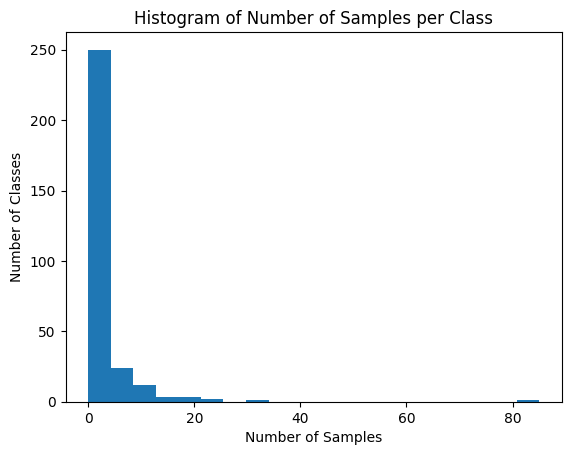

In [13]:
num_per_class = y_test.sum(axis=0)
print(num_per_class.shape) # should be 296, the number of classes
plt.hist(num_per_class, bins=20)
plt.title('Histogram of Number of Samples per Class')
plt.xlabel('Number of Samples')
plt.ylabel('Number of Classes')
plt.show()

### Calculate accuracy, informed by class balance findings

In [14]:
# calculate accuracy
accuracy = accuracy_score(y_test.argmax(axis=1), test_output.argmax(axis=1))
print(f"Accuracy: {accuracy}")

# calculate precision
precision = precision_score(y_test.argmax(axis=1), test_output.argmax(axis=1), average='weighted', zero_division=0)
print(f"Precision: {precision}")

# calculate recall
recall = recall_score(y_test.argmax(axis=1), test_output.argmax(axis=1), average='weighted', zero_division=0)
print(f"Recall: {recall}")

# calculate sensitivity and specificity
sensitivity, specificity = weighted_sensitivity_specificity(conf_matrix)
print(f"Sensitivity: {sensitivity}")
print(f"Specificity: {specificity}")

# calculate balanced accuracy
balanced_accuracy = (sensitivity + specificity) / 2
print(f"Balanced Accuracy: {balanced_accuracy}")

Accuracy: 0.8702702702702703
Precision: 0.860633806080865
Recall: 0.8702702702702703
Sensitivity: 0.8702702702702703
Specificity: 0.9979480866717768
Balanced Accuracy: 0.9341091784710236
